Інсталюємо та імпортуємо бібліотеки numpy та matplotlib

In [ ]:
pip install numpy matplotlib

In [7]:
import numpy as np
import matplotlib.pyplot as plt

Будуємо візуалізацію Лінкса з файлу лабараторної

In [9]:
lynx = np.array([
    [209.70, 368.42], [157.63, 332.16], [118.82, 284.21], [80.95, 224.56], [43.08, 244.44],
    [20.36, 266.67], [-4.26, 293.57], [2.37, 263.16], [-20.36, 292.40], [-39.29, 299.42],
    [-21.30, 259.65], [-50.65, 267.84], [-39.29, 242.11], [-55.38, 240.94], [-100.83, 300.58],
    [-149.11, 345.03], [-172.78, 361.40], [-189.82, 300.58], [-192.66, 225.73], [-181.30, 145.03],
    [-168.05, 104.09], [-184.14, 66.67], [-186.98, 31.58], [-183.20, 3.51], [-208.76, -4.68],
    [-197.40, -29.24], [-182.25, -44.44], [-203.08, -43.27], [-172.78, -92.40], [-131.12, -126.32],
    [-101.78, -147.37], [-74.32, -163.74], [-110.30, -224.56], [-143.43, -287.72], [-161.42, -240.94],
    [-282.60, -221.05], [-388.64, -205.85], [-370.65, -301.75], [-339.41, -397.66], [18.46, -397.66],
    [345.09, -400.00], [359.29, -378.95], [367.81, -342.69], [346.98, -362.57], [363.08, -302.92],
    [357.40, -243.27], [348.88, -266.67], [336.57, -201.17], [290.18, -135.67], [240.00, -118.13],
    [258.93, -164.91], [257.99, -228.07], [252.31, -271.35], [256.09, -333.33], [247.57, -359.06],
    [230.53, -307.60], [194.56, -238.60], [160.47, -181.29], [120.71, -149.71], [165.21, -132.16],
    [201.18, -100.58], [183.20, -99.42], [221.07, -73.68], [253.25, -24.56], [222.01, -23.39],
    [251.36, -1.17], [262.72, 24.56], [234.32, 25.73], [214.44, 42.11], [202.13, 60.82],
    [220.12, 101.75], [234.32, 160.23], [240.00, 230.41], [232.43, 316.96]
])

In [ ]:
L = lynx.T
print(L.shape)

(2, 74)


Пишемо функцію для візуалізації в matplotlib 2D

In [32]:
def plot_shape(L, title="", color="#6B8EAD", ax=None, lim=450):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    x = np.append(L[0], L[0, 0])
    y = np.append(L[1], L[1, 0])

    ax.fill(x, y, color=color, alpha=0.85)
    ax.plot(x, y, color="black", linewidth=0.7)

    ax.axhline(0, color="gray", linewidth=0.6, zorder=0)
    ax.axvline(0, color="gray", linewidth=0.6, zorder=0)

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    return ax

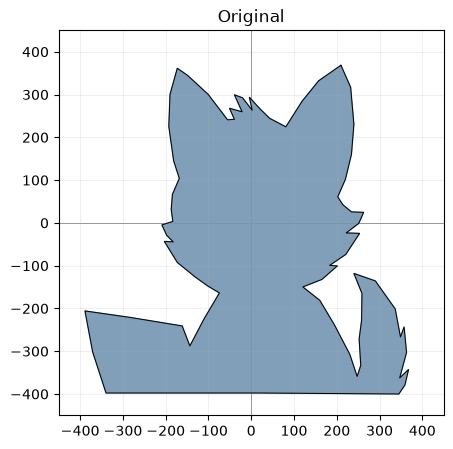

In [33]:
plot_shape(L, "Original")
plt.show()

# PART_1

### TASK_1

In [73]:
def stretch(X, a, b):
    A = np.array([[a,0],
                 [0, b]])
    X = X.copy()
    return A@X, A

In [74]:
def shear(X, a, b):
    A = np.array([[1, a],
                 [b, 1]])
    X = X.copy()
    return A@X, A

In [80]:
def reflection(X, a, b):
    A = np.array([[a**2 - b**2, 2*a*b],
                  [2*a*b, b**2 - a**2]])/(a**2 + b**2)
    X = X.copy()
    return A@X, A

In [76]:
def rotation(X, a):
    a = np.radians(a)
    A = np.array([[np.cos(a), -np.sin(a)],
                  [np.sin(a), np.cos(a)]])
    X = X.copy()
    return A@X, A

Створили функції для лінійних трансформацій. Тепер створимо трансормовані зображення та запишемо їх у окремі змінні

In [139]:
L_stretched = stretch(L, 1.5, 0.7)
L_sheared = shear(L, 0.5, 0.5)
L_reflected = reflection(L, 1, 1)
L_rotated = rotation(L, 60)

Створимо функцію для зручного відображення початкового зображення та зміненої матриці

In [140]:
def show(L_original, L_new, A, title, lim = 700):
    print(f"{title}\nМатриця перетворення:\n{A}")
    _ , axes = plt.subplots(1, 2, figsize=(11, 5.5))
    plot_shape(L_original, "Original", ax=axes[0], color="gray", lim=lim)
    plot_shape(L_new, title, ax=axes[1], color="#6B8EAD", lim=lim)
    plt.tight_layout()
    plt.show()


Stretched
Матриця перетворення:
[[1.5 0. ]
 [0.  0.7]]


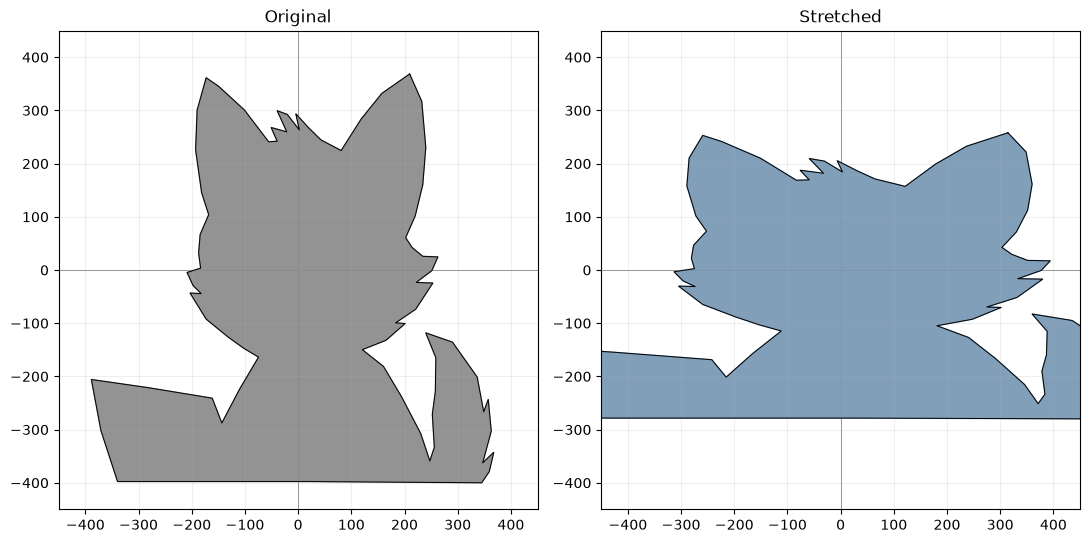

In [141]:
show(L, L_stretched[0], L_stretched[1], "Stretched", lim = 450)

Sheared
Матриця перетворення:
[[1.  0.5]
 [0.5 1. ]]


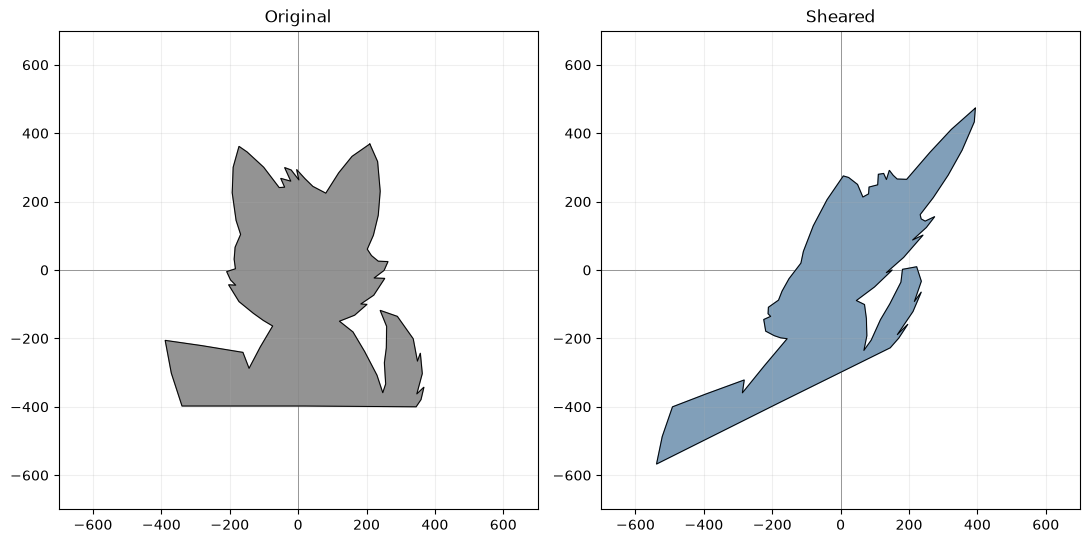

In [142]:
show(L, L_sheared[0], L_sheared[1], "Sheared")

Reflected
Матриця перетворення:
[[0. 1.]
 [1. 0.]]


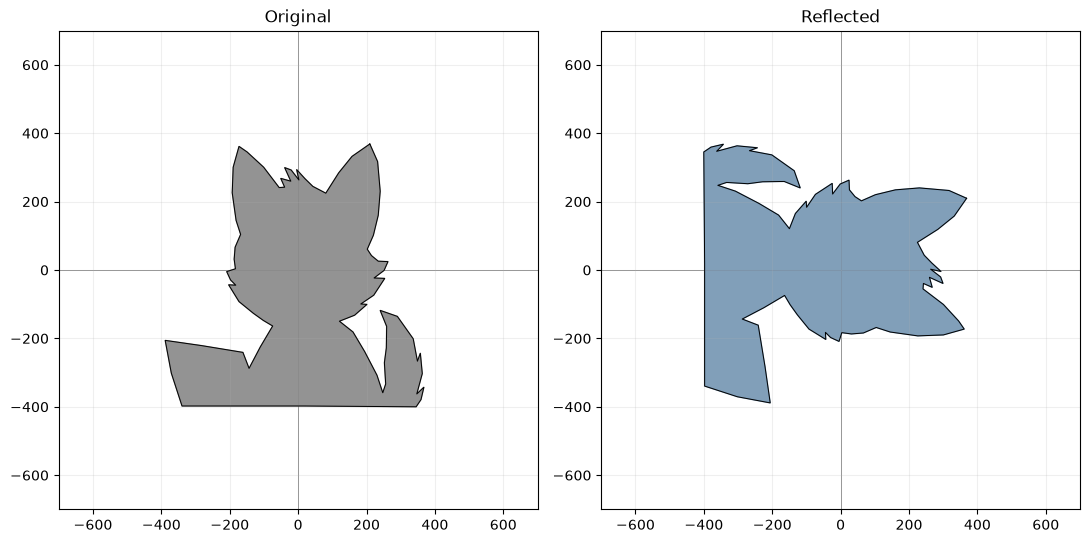

In [143]:
show(L, L_reflected[0], L_reflected[1], "Reflected")

Rotated
Матриця перетворення:
[[ 0.5       -0.8660254]
 [ 0.8660254  0.5      ]]


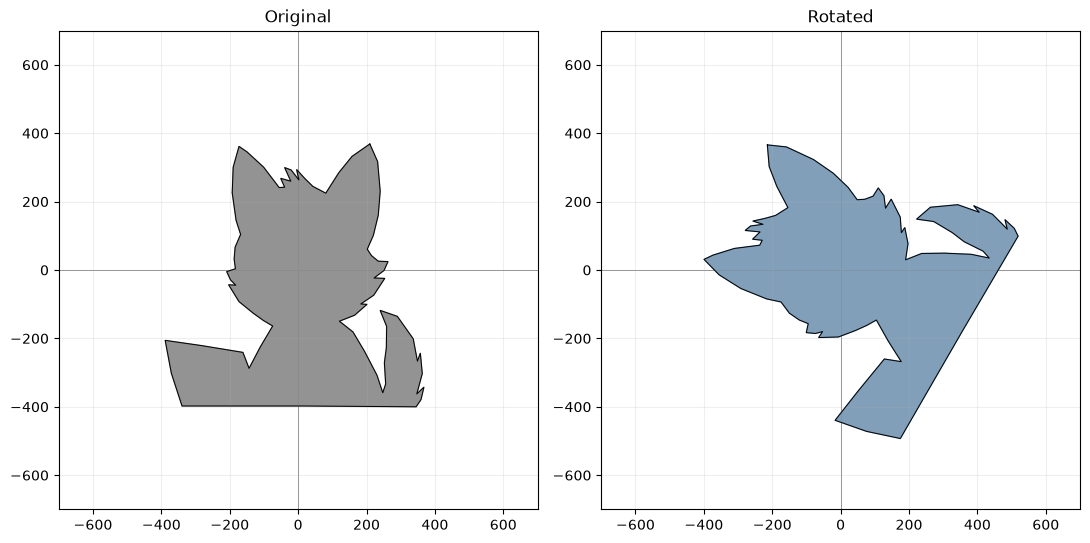

In [144]:
show(L, L_rotated[0], L_rotated[1], "Rotated")

### TASK_2

In [149]:
L_combo1 = stretch(shear(rotation(L, 60)[0], 0.5, 0.5)[0], 1.5, 0.7)
Combo1_matrix = L_stretched[1]@(L_sheared[1]@L_rotated[1])
L_combo2 = shear(rotation(stretch(L, 1.5, 0.7)[0], 60)[0], 0.5, 0.5)
Combo2_matrix = L_sheared[1]@(L_rotated[1]@L_stretched[1])
L_combo3 = rotation(stretch(shear(L, 0.5, 0.5)[0], 1.5, 0.7)[0], 60)
Combo3_matrix = L_rotated[1]@(L_stretched[1]@L_sheared[1])

Матриця перетворення:
[[ 1.39951905 -0.92403811]
 [ 0.78121778  0.04689111]]


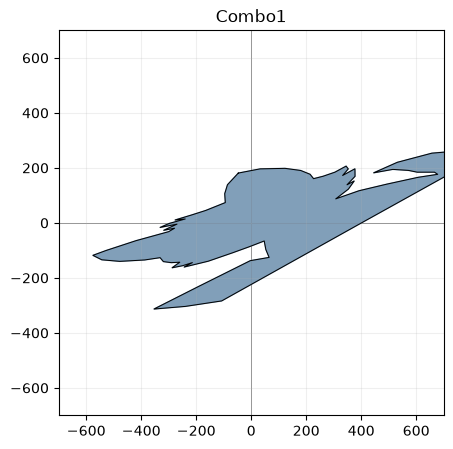

In [150]:
plot_shape(L_combo1[0], "Combo1", lim = 700)
print(f"Матриця перетворення:\n{Combo1_matrix}")
plt.show()

Матриця перетворення:
[[ 1.39951905 -0.43121778]
 [ 1.67403811  0.04689111]]


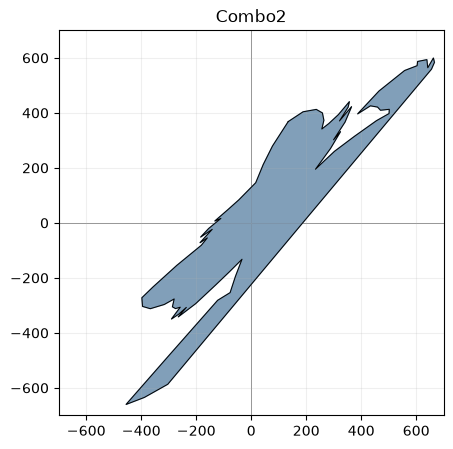

In [151]:
plot_shape(L_combo2[0], "Combo2", lim = 700)
print(f"Матриця перетворення:\n{Combo2_matrix}")
plt.show()

Матриця перетворення:
[[ 0.44689111 -0.23121778]
 [ 1.47403811  0.99951905]]


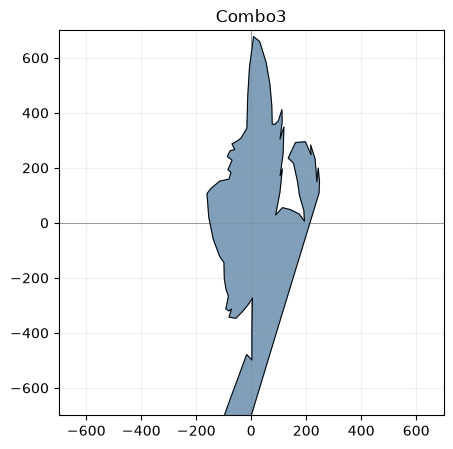

In [152]:
plot_shape(L_combo3[0], "Combo3", lim = 700)
print(f"Матриця перетворення:\n{Combo3_matrix}")
plt.show()

Результат залежить від порядку, бо множення матриць некомутативне